In [5]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

In [6]:
from sklearn.pipeline import Pipeline #step-by-step recipe
from sklearn.decomposition import PCA #It reduces the number of features by combining them into new ones (called principal components) that keep the most important information.
from sklearn.cross_decomposition import PLSRegression #Partial Least Squares Regression, selects variables explain variance
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
from l0bnb import fit_path #does subset selection (finds the path)


In [7]:
df = pd.read_csv('/Users/markpotter/Documents/School/MA/ML/Project/Doing Well by Doing Good/data/data_rent_100710.txt', sep='\t')

In [8]:
df.head()

,CS_PropertyID,id,idgreen,EPA_ID,size,empl_gr,Rent,leasing_rate,stories,age,...,Gas_Costs,Electricity_Costs,SEP_Rating,SEP_current,Electricity,Natural_Gas,Other_Energy,Site_EUI,Source_EUI,Emissions
0,419750,1082,1082.0,1228695,378501,3.70%,26.77,84.02,16.0,9.0,...,0.0101,0.0289,75.0,84.0,27752130.0,0.0,0.0,72.6,242.6,5777.0
1,248122,984,984.0,23374,64452,2.38%,28.20,100.00,2.0,19.0,...,0.0103,0.0378,82.0,86.0,3103208.0,860542.0,0.0,61.5,174.8,465.0
2,1533602,250,250.0,23099,195253,7.55%,21.37,74.55,10.0,18.0,...,0.0105,0.0223,81.0,84.0,14466325.0,0.0,0.0,74.1,247.5,2749.0
3,731586,193,193.0,1058239,252193,2.97%,17.50,85.63,7.0,4.0,...,0.0141,0.0262,79.0,90.0,15381566.0,0.0,0.0,50.4,168.3,2469.0
4,445519,973,973.0,1331126,121969,3.27%,19.75,100.00,4.0,7.0,...,0.0138,0.0229,84.0,84.0,6833393.0,0.0,0.0,56.1,187.3,1492.0


In [9]:
df.columns

Index(['CS_PropertyID', 'id', 'idgreen', 'EPA_ID', 'size', 'empl_gr', 'Rent',
       'leasing_rate', 'stories', 'age', 'renovated', 'class_a', 'class_b',
       'class_c', 'LEED', 'Energystar', 'green_rating', 'net', 'amenities',
       'cd_total_07', 'hd_total07', 'total_dd_07', 'Precipitation',
       'Gas_Costs', 'Electricity_Costs', 'SEP_Rating', 'SEP_current',
       'Electricity', 'Natural_Gas', 'Other_Energy', 'Site_EUI ', 'Source_EUI',
       'Emissions '],
      dtype='object')

In [10]:
np.shape(df)

(8183, 33)

In [11]:
df.describe()

,CS_PropertyID,id,idgreen,size,Rent,leasing_rate,stories,age,renovated,class_a,...,Gas_Costs,Electricity_Costs,SEP_Rating,SEP_current,Electricity,Natural_Gas,Other_Energy,Site_EUI,Source_EUI,Emissions
count,8.183000e+03,8183.000000,694.000000,8.183000e+03,8183.000000,8183.000000,8169.000000,7903.000000,8183.000000,8183.000000,...,8183.000000,8183.000000,454.000000,439.000000,4.540000e+02,4.540000e+02,4.540000e+02,454.000000,454.000000,454.000000
mean,5.142257e+05,586.352194,619.870317,2.276211e+05,28.286280,82.010334,13.266985,47.228774,0.370280,0.387144,...,0.011455,0.031161,85.292952,87.505695,2.279368e+07,1.675413e+06,1.749109e+06,63.538106,193.828414,4624.519824
std,8.950113e+05,400.553251,394.103436,2.947186e+05,15.403867,22.168668,12.222326,32.210407,0.482909,0.487127,...,0.002804,0.008899,6.952065,6.552516,2.289860e+07,4.290417e+06,8.092785e+06,15.463872,42.182666,5554.229466
min,1.000000e+00,1.000000,1.000000,5.000000e+02,2.980000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.009487,0.017800,75.000000,63.000000,8.011700e+04,0.000000e+00,0.000000e+00,6.800000,22.700000,0.000000
25%,1.579260e+05,264.500000,289.250000,4.557800e+04,19.130000,77.210000,4.000000,23.000000,0.000000,0.000000,...,0.010296,0.023300,79.000000,84.000000,7.622428e+06,0.000000e+00,0.000000e+00,55.000000,169.475000,1195.500000
50%,3.141240e+05,473.000000,486.000000,1.205000e+05,25.000000,89.370000,10.000000,34.000000,0.000000,0.000000,...,0.010296,0.032737,85.000000,88.000000,1.635568e+07,3.810350e+04,0.000000e+00,62.800000,194.950000,2878.500000
75%,4.704765e+05,1044.000000,1046.750000,2.848270e+05,34.000000,96.385000,18.000000,79.000000,1.000000,1.000000,...,0.011816,0.037808,91.000000,92.000000,3.115227e+07,1.569739e+06,0.000000e+00,72.075000,221.975000,6038.500000
max,6.208103e+06,1230.000000,1230.000000,3.781045e+06,271.620000,100.000000,110.000000,187.000000,1.000000,1.000000,...,0.028914,0.062800,100.000000,100.000000,2.086734e+08,6.138299e+07,1.192657e+08,122.600000,311.600000,62335.000000


In [ ]:
df['id'].nunique()

694

In [13]:
df.isnull().sum()

CS_PropertyID           0
id                      0
idgreen              7489
EPA_ID               7698
size                    0
empl_gr                78
Rent                    0
leasing_rate            0
stories                14
age                   280
renovated               0
class_a                 0
class_b                 0
class_c                 0
LEED                    0
Energystar              0
green_rating            0
net                     0
amenities               0
cd_total_07             0
hd_total07              0
total_dd_07             0
Precipitation           0
Gas_Costs               0
Electricity_Costs       0
SEP_Rating           7729
SEP_current          7744
Electricity          7729
Natural_Gas          7729
Other_Energy         7729
Site_EUI             7729
Source_EUI           7729
Emissions            7729
dtype: int64

In [14]:

# 1. Define your list of variables
variables = [
    "green_rating",
    "LEED",
    "Energystar",
    "Rent",
    "leasing_rate",
    "size",
    "age",
    "stories",
    "Gas_Costs",
    "Electricity_Costs",
    "renovated",
    "class_a",
    "class_b",
    "class_c",
    "net",
    "amenities",
    "total_dd_07"
]

# 2. Filter existing columns, compute stats, and transpose 
# (.T flips it so variables are rows and stats are columns, matching your layout)
valid_vars = [v for v in variables if v in df.columns]
summary_df = (
    df[valid_vars]
    .describe()
    .T[["mean", "50%", "std", "min", "max"]]
    .rename(columns={"50%": "Median", "mean": "Mean", "std": "Std. Dev.", "min": "Min", "max": "Max"})
)

# Optional: Format numbers to 2 decimal places for clean display
summary_df = summary_df.round(2)

# -------------------------------------------------------------
# A. View the table interactively inside your Jupyter notebook:
display(summary_df)



,Mean,Median,Std. Dev.,Min,Max
green_rating,0.08,0.00,0.28,0.00,1.00
LEED,0.01,0.00,0.08,0.00,1.00
Energystar,0.08,0.00,0.27,0.00,1.00
Rent,28.29,25.00,15.40,2.98,271.62
leasing_rate,82.01,89.37,22.17,0.00,100.00
size,227621.15,120500.00,294718.62,500.00,3781045.00
age,47.23,34.00,32.21,0.00,187.00
stories,13.27,10.00,12.22,1.00,110.00
Gas_Costs,0.01,0.01,0.00,0.01,0.03
Electricity_Costs,0.03,0.03,0.01,0.02,0.06


In [15]:
# -------------------------------------------------------------
# B. Generate and print the LaTeX code to copy into your document:
latex_output = summary_df.to_latex(
    escape=False, 
    column_format="lccccc",
    caption="Summary Statistics --- Key Variables",
    label="tab:summary_stats"
)
print(latex_output)

\begin{table}
\caption{Summary Statistics --- Key Variables}
\label{tab:summary_stats}
\begin{tabular}{lccccc}
\toprule
 & Mean & Median & Std. Dev. & Min & Max \\
\midrule
green_rating & 0.080000 & 0.000000 & 0.280000 & 0.000000 & 1.000000 \\
LEED & 0.010000 & 0.000000 & 0.080000 & 0.000000 & 1.000000 \\
Energystar & 0.080000 & 0.000000 & 0.270000 & 0.000000 & 1.000000 \\
Rent & 28.290000 & 25.000000 & 15.400000 & 2.980000 & 271.620000 \\
leasing_rate & 82.010000 & 89.370000 & 22.170000 & 0.000000 & 100.000000 \\
size & 227621.150000 & 120500.000000 & 294718.620000 & 500.000000 & 3781045.000000 \\
age & 47.230000 & 34.000000 & 32.210000 & 0.000000 & 187.000000 \\
stories & 13.270000 & 10.000000 & 12.220000 & 1.000000 & 110.000000 \\
Gas_Costs & 0.010000 & 0.010000 & 0.000000 & 0.010000 & 0.030000 \\
Electricity_Costs & 0.030000 & 0.030000 & 0.010000 & 0.020000 & 0.060000 \\
renovated & 0.370000 & 0.000000 & 0.480000 & 0.000000 & 1.000000 \\
class_a & 0.390000 & 0.000000 & 0.490000 & 0

In [19]:
X = df.drop(columns=['Rent'])

In [24]:
Y = df['Rent']

In [38]:
['EPA_ID', 'Rent', 'Site_EUI', 'Emissions']

cols_to_drop = [
    # ID variables
    'CS_PropertyID', 'id', 'idgreen',
    
    # All variables from Electricity_Costs onwards
    'Electricity_Costs', 'SEP_Rating', 'SEP_current', 'Electricity', 
    'Natural_Gas', 'Other_Energy'
]

# Drop them fro

In [43]:
import numpy as np

# 1. Keep only numerical/quantitative columns
X_quant = X.select_dtypes(include='number')

X_quant = X_quant.drop(columns=[])

# 2. Your original operations applied to the quantitative subset
Xs = X_quant - X_quant.mean(0)[None, :]
X_scale = X_quant.std(0)
Xs = Xs / X_scale[None, :]

lambdas = 10**np.linspace(8, -2, 100) / Y.std()
soln_array = skl.ElasticNet.path(
    Xs, 
    Y, 
    l1_ratio=0., 
    alphas=lambdas
)[1]

soln_array.shape

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

In [44]:


# 1. Combine quantitative X and Y, then drop any rows with NaN values
data = X.select_dtypes(include='number').copy()
data['Y'] = Y
data = data.dropna()

X_quant = data.drop(columns=cols_to_drop)
Y_clean = data['Y']

# 2. Standardize using StandardScaler
scaler = StandardScaler()
Xs = scaler.fit_transform(X_quant)

# 3. Fit the path using the cleaned data
lambdas = 10**np.linspace(8, -2, 100) / Y_clean.std()
soln_array = skl.ElasticNet.path(
    Xs, 
    Y_clean, 
    l1_ratio=0.1, 
    alphas=lambdas
)[1]

soln_array.shape

(22, 100)

In [42]:
X_quant.columns

Index(['size', 'leasing_rate', 'stories', 'age', 'renovated', 'class_a',
       'class_b', 'class_c', 'LEED', 'Energystar', 'green_rating', 'net',
       'amenities', 'cd_total_07', 'hd_total07', 'total_dd_07',
       'Precipitation', 'Gas_Costs', 'Site_EUI ', 'Source_EUI', 'Emissions ',
       'Y'],
      dtype='object')

In [33]:
soln_path = pd.DataFrame(soln_array.T,
                         columns=X_quant.columns,
                         index=-np.log(lambdas))
soln_path.index.name = 'negative log(lambda)'
soln_path

,CS_PropertyID,id,idgreen,size,leasing_rate,stories,age,renovated,class_a,class_b,...,Gas_Costs,Electricity_Costs,SEP_Rating,SEP_current,Electricity,Natural_Gas,Other_Energy,Site_EUI,Source_EUI,Emissions
negative log(lambda),,,,,,,,,,,,,,,,,,,,,
-15.945973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-15.713389,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-15.480804,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-15.248220,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-15.015636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6.149540,-2.362702,0.637085,0.636830,1.647334,0.439847,-1.826682,1.700259,-1.596102,1.121548,-1.197935,...,1.661453,3.609348,0.651896,0.420583,7.260311,-0.992757,1.869970,0.642353,1.717859,-7.615968
6.382125,-2.363711,0.637799,0.637547,1.639005,0.437471,-1.844163,1.702422,-1.597483,1.121842,-1.198395,...,1.669042,3.607741,0.655145,0.415499,7.362721,-0.994016,1.878802,0.645803,1.705882,-7.697734
6.614709,-2.364493,0.638370,0.638120,1.631790,0.435547,-1.858170,1.704125,-1.598574,1.122079,-1.198769,...,1.675161,3.606361,0.657777,0.411343,7.446065,-0.995030,1.885955,0.648718,1.695956,-7.764024


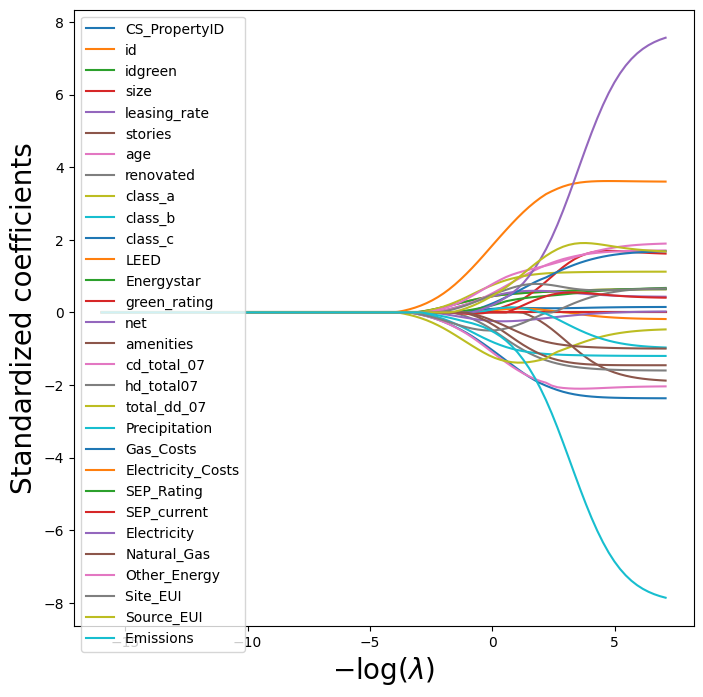

In [41]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel(r'$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20)
ax.legend(loc='upper left');
